# Riding the Forecast: $\text{How Weather Conditions Affect Divvy Bikes' Performance}$
## By Julia Hinds
March 2026

---
<img src="https://upload.wikimedia.org/wikipedia/commons/a/a4/Dante_Park_td_%282019-06-18%29_25_-_Citi_Bike.jpg" width=600px>


# Introduction

This notebook analyzes how weather conditions influenced bike-share ridership in Chicago during August 2025. The goal is not only to understand how temperature, rain, and other weather variables affect overall demand, but also to determine whether those patterns differ across rider types and stations. 

### Datasets
- Trip Data — bike_data.csv — Ride data for August 2025 - pulled from Divvy Bikes public data: https://divvybikes.com/system-data
- Hourly Chicago weather data for August 2025 — weather_data.csv - pulled from Open-Meteo api 



### Settings for the Notebook
First, we'll want to import relevent libraries and load the all the data (originally stored in CSV files). It is assumed that the data has been locally downloaded and is inside an "input/" directory.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import folium
from scipy.stats import gaussian_kde
from math import radians, sin, cos, sqrt, atan2
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 100)

In [2]:
# Can't push inputs to git, need to download locally and put in input directory!
bike = pd.read_csv("input/202508-divvy-tripdata.csv")
weather = pd.read_csv("input/weather_data.csv")

------------------------------------------------

# I. Data Wrangling & Exploration

## Investigating the raw data

Bike data: trip-level records with start/end times, station info, coordinates, and rider type

Weather data: hourly weather observations such as temperature, precipitation, wind, and visibility

In [3]:
# First taking a quick peak at how it's stored
print("Bike shape:", bike.shape)
print("Weather shape:", weather.shape)

display(bike.head())
display(weather.head())

Bike shape: (790177, 13)
Weather shape: (744, 15)


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,5C00A6B5A60E4AFC,electric_bike,2025-08-28 15:56:46.803,2025-08-28 16:11:54.890,NaN,NaN,NaN,NaN,41.88,-87.64,41.89,-87.62,casual
1,FB25D4B923656D01,electric_bike,2025-08-27 19:15:53.059,2025-08-27 19:34:13.683,NaN,NaN,NaN,NaN,41.95,-87.64,41.89,-87.61,casual
2,C665B0EC937C860C,electric_bike,2025-08-27 20:27:31.394,2025-08-27 20:38:29.890,NaN,NaN,NaN,NaN,41.92,-87.65,41.90,-87.64,casual
3,C68C54D5FD9717C2,electric_bike,2025-08-28 15:33:21.055,2025-08-28 15:39:58.052,NaN,NaN,NaN,NaN,41.89,-87.65,41.88,-87.65,casual
4,902D69C29B0E65F8,electric_bike,2025-08-28 09:59:44.846,2025-08-28 10:11:17.343,NaN,NaN,NaN,NaN,41.98,-87.68,41.95,-87.70,casual


,time,temp,apparent_temperature,dewpoint,humidity,precipitation,rain,showers,snowfall,windspeed_10m,windgusts_10m,winddirection_10m,visibility,cloudcover,is_day
0,2025-08-01 00:00:00,66.2,64.9,58.5,76,0.0,0.0,0.0,0.0,9.8,23.0,7,NaN,74,1
1,2025-08-01 01:00:00,66.1,66.6,60.7,83,0.0,0.0,0.0,0.0,7.6,20.8,4,NaN,100,1
2,2025-08-01 02:00:00,66.3,68.9,63.2,90,0.0,0.0,0.0,0.0,4.9,15.9,21,NaN,100,1
3,2025-08-01 03:00:00,66.6,69.2,64.0,91,0.0,0.0,0.0,0.0,5.8,11.6,58,NaN,97,1
4,2025-08-01 04:00:00,66.3,68.5,63.0,89,0.0,0.0,0.0,0.0,5.8,12.5,71,NaN,88,1


In [4]:
# Add column "ride_length" to make things easier
bike["started_at"] = pd.to_datetime(bike["started_at"])
bike["ended_at"] = pd.to_datetime(bike["ended_at"])

# Compute ride duration
bike["ride_length"] = bike["ended_at"] - bike["started_at"]

# Convert to HH:MM:SS format
bike["ride_length"] = bike["ride_length"].dt.total_seconds().astype(int)

bike["ride_length"] = bike["ride_length"].apply(
    lambda x: f"{x//3600:02}:{(x%3600)//60:02}:{x%60:02}"
)
bike

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_length
0,5C00A6B5A60E4AFC,electric_bike,2025-08-28 15:56:46.803,2025-08-28 16:11:54.890,NaN,NaN,NaN,NaN,41.880000,-87.640000,41.89,-87.62,casual,00:15:08
1,FB25D4B923656D01,electric_bike,2025-08-27 19:15:53.059,2025-08-27 19:34:13.683,NaN,NaN,NaN,NaN,41.950000,-87.640000,41.89,-87.61,casual,00:18:20
2,C665B0EC937C860C,electric_bike,2025-08-27 20:27:31.394,2025-08-27 20:38:29.890,NaN,NaN,NaN,NaN,41.920000,-87.650000,41.90,-87.64,casual,00:10:58
3,C68C54D5FD9717C2,electric_bike,2025-08-28 15:33:21.055,2025-08-28 15:39:58.052,NaN,NaN,NaN,NaN,41.890000,-87.650000,41.88,-87.65,casual,00:06:36
4,902D69C29B0E65F8,electric_bike,2025-08-28 09:59:44.846,2025-08-28 10:11:17.343,NaN,NaN,NaN,NaN,41.980000,-87.680000,41.95,-87.70,casual,00:11:32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
790172,5A8E1431C96F6C2A,electric_bike,2025-08-28 12:42:26.506,2025-08-28 13:03:28.283,Central Park Ave & Ardmore Ave,CHI01863,NaN,NaN,41.986608,-87.718767,41.93,-87.71,member,00:21:01
790173,698907CE7C5354C2,electric_bike,2025-08-10 22:28:40.751,2025-08-10 22:34:43.681,Desplaines St & Kinzie St,CHI00517,NaN,NaN,41.888716,-87.644448,41.89,-87.65,casual,00:06:02
790174,445ED4E4CF9E652D,electric_bike,2025-08-14 19:54:03.094,2025-08-14 20:01:02.776,Western Ave & Ardmore Ave,CHI00936,NaN,NaN,41.986764,-87.689880,41.98,-87.69,member,00:06:59
790175,54DADB4143D8CB37,electric_bike,2025-08-14 21:37:47.243,2025-08-14 21:40:31.607,Sheffield Ave & Addison St,CHI02054,NaN,NaN,41.947017,-87.654418,41.95,-87.65,member,00:02:44


## Data Preparation

Before analyzing weather effects, the trip and weather data must be cleaned and aligned. This section prepares the bike-share trip data, repairs missing station metadata where possible, removes unrealistic ride durations, and merges the cleaned trip data with hourly weather observations so that ridership and weather can be analyzed together.

In [5]:
# Check missing entries and duplicates

print("Bike missing values:")
display(bike.isnull().sum().sort_values(ascending=False))

print("Weather missing values:")
display(weather.isnull().sum().sort_values(ascending=False))

Bike missing values:


end_station_name      184760
end_station_id        184760
start_station_name    177121
start_station_id      177121
end_lat                  693
end_lng                  693
ride_id                    0
rideable_type              0
started_at                 0
ended_at                   0
start_lat                  0
start_lng                  0
member_casual              0
ride_length                0
dtype: int64

Weather missing values:


visibility              744
time                      0
temp                      0
apparent_temperature      0
dewpoint                  0
humidity                  0
precipitation             0
rain                      0
showers                   0
snowfall                  0
windspeed_10m             0
windgusts_10m             0
winddirection_10m         0
cloudcover                0
is_day                    0
dtype: int64

In [6]:
print("Duplicate bike rows:", bike.duplicated().sum())
print("Duplicate weather rows:", weather.duplicated().sum())
# No duplicates (good news!) 

Duplicate bike rows: 0
Duplicate weather rows: 0


## Imput Missing Station Names and IDs from Latitude/Longitude
A major data quality issue in the bike data is that some trips have missing station names or IDs, even when coordinates are present. Instead of dropping those trips, we can recover many of them by using known station-coordinate pairs elsewhere in the dataset.

This is done by:
1. Building a lookup table from known stations
2. Matching missing stations by rounded coordinates
3. Using nearest known station within a short radius as a fallback

Important to note: 0.01 degree latitude/longitude is about ~1.11 km or ~0.69 miles

In [7]:
# Build station reference tables (using df.notna() to detect existing (non-missing) values within the df)
start_ref = (
    bike.loc[
        bike["start_station_name"].notna() &
        bike["start_station_id"].notna() &
        bike["start_lat"].notna() &
        bike["start_lng"].notna(),
        ["start_station_name", "start_station_id", "start_lat", "start_lng"]
    ]
    .rename(columns={
        "start_station_name": "station_name",
        "start_station_id": "station_id",
        "start_lat": "lat",
        "start_lng": "lng"
    })
)

end_ref = (
    bike.loc[
        bike["end_station_name"].notna() &
        bike["end_station_id"].notna() &
        bike["end_lat"].notna() &
        bike["end_lng"].notna(),
        ["end_station_name", "end_station_id", "end_lat", "end_lng"]
    ]
    .rename(columns={
        "end_station_name": "station_name",
        "end_station_id": "station_id",
        "end_lat": "lat",
        "end_lng": "lng"
    })
)

station_ref_raw = pd.concat([start_ref, end_ref], ignore_index=True)

print("Reference rows before deduplication:", len(station_ref_raw))
display(station_ref_raw.head())

Reference rows before deduplication: 1218473


,station_name,station_id,lat,lng
0,California Ave & Milwaukee Ave,CHI00307,41.922695,-87.697153
1,California Ave & Milwaukee Ave,CHI00307,41.922695,-87.697153
2,Sayre Ave & Diversey Ave,CHI01871,41.930980,-87.801060
3,California Ave & Milwaukee Ave,CHI00307,41.922695,-87.697153
4,Milwaukee Ave & Fullerton Ave,CHI02075,41.924690,-87.700600


In [8]:
# Create one station per rounded coordinate pair
station_ref_raw["lat_round"] = station_ref_raw["lat"].round(4)
station_ref_raw["lng_round"] = station_ref_raw["lng"].round(4)

# Coordinates may differ by tiny floating-point noise even for the same physical station. Rounding 
#   to 4 decimal places gives a stable geographic match while preserving station-level precision.
#   -> i.e. some places (like Avenue O & 134th St) are the same up to the 4th decimal: 
#         (41.6519, -87.5396) and (41.6519, -87.5397)

station_ref = (
    station_ref_raw
    .groupby(["lat_round", "lng_round", "station_name", "station_id"])
    .size()
    .reset_index(name="count")
    .sort_values(["lat_round", "lng_round", "count"], ascending=[True, True, False])
    .drop_duplicates(subset=["lat_round", "lng_round"])
    .reset_index(drop=True)
)

print("Unique station coordinate pairs:", len(station_ref))
display(station_ref.head())

Unique station coordinate pairs: 5384


,lat_round,lng_round,station_name,station_id,count
0,41.6485,-87.5461,Hegewisch Metra Station,CHI00876,12
1,41.6519,-87.5396,Avenue O & 134th St,CHI00843,20
2,41.6535,-87.5470,Baltimore Ave & 133rd St,CHI01947,19
3,41.6538,-87.6172,Indiana Ave & 133rd St,CHI01933,5
4,41.6567,-87.5988,Altgeld Gardens,CHI00849,5


In [9]:
# Create rounded coordinate columns in the bike data
bike["start_lat_round"] = bike["start_lat"].round(4)
bike["start_lng_round"] = bike["start_lng"].round(4)
bike["end_lat_round"] = bike["end_lat"].round(4)
bike["end_lng_round"] = bike["end_lng"].round(4)

In [10]:
# Fill station fields by exact coordinate match

bike = bike.merge(
    station_ref[["lat_round", "lng_round", "station_name", "station_id"]].rename(columns={
        "lat_round": "start_lat_round",
        "lng_round": "start_lng_round",
        "station_name": "start_station_name_lookup",
        "station_id": "start_station_id_lookup"
    }),
    on=["start_lat_round", "start_lng_round"],
    how="left" # keeps all rows from the left df and brings in matching rows from the right df; 
               #    non-matching rows in the right df will be filled with NaN
)

bike = bike.merge(
    station_ref[["lat_round", "lng_round", "station_name", "station_id"]].rename(columns={
        "lat_round": "end_lat_round",
        "lng_round": "end_lng_round",
        "station_name": "end_station_name_lookup",
        "station_id": "end_station_id_lookup"
    }),
    on=["end_lat_round", "end_lng_round"],
    how="left" # keeps all rows from the left df and brings in matching rows from the right df; 
               #    non-matching rows in the right df will be filled with NaN
)

# Use df.fillna() to replace missing (NaN) values in df with a name lookup
bike["start_station_name"] = bike["start_station_name"].fillna(bike["start_station_name_lookup"])
bike["start_station_id"] = bike["start_station_id"].fillna(bike["start_station_id_lookup"])

bike["end_station_name"] = bike["end_station_name"].fillna(bike["end_station_name_lookup"])
bike["end_station_id"] = bike["end_station_id"].fillna(bike["end_station_id_lookup"])

In [11]:
# If a trip start/end coordinate is very close to a known station location, it likely belongs to that station.
#    Can compute geographic distance using the haversine formula and assign the nearest station if it is within 
#    a conservative threshold. This avoids forcing station assignments for trips that might actually start/end 
#    away from docks.
# Ref: https://en.wikipedia.org/wiki/Haversine_formula

EARTH_RADIUS_M = 6371000 # Earth's radius in meters
MAX_DISTANCE_M = 150 # max distance in meters

def distance(lat1, lon1, lat2, lon2):
    """
    Compute haversine distance in meters between one point
    (lat1, lon1) and arrays of points (lat2, lon2).
    
    Ref: https://en.wikipedia.org/wiki/Haversine_formula
    """
    lat1, lon1 = np.radians(lat1), np.radians(lon1)
    lat2, lon2 = np.radians(lat2), np.radians(lon2)
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return EARTH_RADIUS_M * c

In [12]:
def fill_station_by_nearest(df, lat_col, lng_col, name_col, id_col, station_ref, max_distance_m=150):
    """
    Fill missing station name/ID by assigning the nearest known station
    within a maximum distance threshold.
    """
    missing_mask = (
        df[name_col].isna() &
        df[id_col].isna() &
        df[lat_col].notna() &
        df[lng_col].notna()
    )
    
    if missing_mask.sum() == 0:
        # check: if there's no missing values, so just return df
        return df
    
    ref_lats = station_ref["lat_round"].values
    ref_lngs = station_ref["lng_round"].values
    ref_names = station_ref["station_name"].values
    ref_ids = station_ref["station_id"].values
    
    missing_rows = df.loc[missing_mask, [lat_col, lng_col]]
    
    for idx, row in missing_rows.iterrows(): # loop through each and see if there's one nearby
        lat = row[lat_col]
        lng = row[lng_col]
        
        distances = distance(lat, lng, ref_lats, ref_lngs) # compute haversine distances
        nearest_idx = np.argmin(distances)
        nearest_distance = distances[nearest_idx]
        
        if nearest_distance <= max_distance_m: # if there's one nearby, assign it to that dock
            df.at[idx, name_col] = ref_names[nearest_idx]
            df.at[idx, id_col] = ref_ids[nearest_idx]
    
    return df

In [13]:
# Apply the function to start and end stations
bike = fill_station_by_nearest(
    bike,
    lat_col="start_lat",
    lng_col="start_lng",
    name_col="start_station_name",
    id_col="start_station_id",
    station_ref=station_ref,
    max_distance_m=MAX_DISTANCE_M
)

bike = fill_station_by_nearest(
    bike,
    lat_col="end_lat",
    lng_col="end_lng",
    name_col="end_station_name",
    id_col="end_station_id",
    station_ref=station_ref,
    max_distance_m=MAX_DISTANCE_M
)

In [14]:
# Clean up temporary columns
cols_to_drop = [
    "start_station_name_lookup", "start_station_id_lookup",
    "end_station_name_lookup", "end_station_id_lookup",
    "start_lat_round", "start_lng_round",
    "end_lat_round", "end_lng_round"
]

bike = bike.drop(columns=[c for c in cols_to_drop if c in bike.columns])

In [15]:
# Evaluate the result
print("Remaining missing start_station_name:", bike["start_station_name"].isna().sum())
print("Remaining missing start_station_id:", bike["start_station_id"].isna().sum())
print("Remaining missing end_station_name:", bike["end_station_name"].isna().sum())
print("Remaining missing end_station_id:", bike["end_station_id"].isna().sum())

Remaining missing start_station_name: 100528
Remaining missing start_station_id: 100528
Remaining missing end_station_name: 105732
Remaining missing end_station_id: 105732


In [16]:
bike[["start_station_name", "start_station_id", "end_station_name", "end_station_id"]].head(10)


,start_station_name,start_station_id,end_station_name,end_station_id
0,Clinton St & Madison St,CHI00233,New St & Illinois St,CHI00279
1,NaN,NaN,NaN,NaN
2,Halsted St & Dickens Ave,CHI00291,NaN,NaN
3,Peoria St & Kinzie St,CHI02098,NaN,NaN
4,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN
8,Clinton St & Madison St,CHI00233,Kingsbury St & Kinzie St,CHI00299
9,LaSalle St & Illinois St,CHI00358,Lincoln Ave & Dickens Ave,CHI02112


Some trips were missing station names or IDs despite containing valid latitude and longitude. Instead of dropping those trips, I reconstructed missing station fields using known station-coordinate pairs elsewhere in the data. I first matched exact rounded coordinates, then applied a nearest-station fallback within 150 meters. This preserved more trips (about 80,000) for station-level analysis while reducing the chance of incorrect assignments.

## Ride Duration

Ride duration is useful both for filtering suspicious trips and for understanding basic rider behavior. Before using this field, I convert it into seconds and inspect the distribution for unrealistic values or likely accidental unlocks.

In [17]:
# Convert ride length to seconds
bike[["h", "m", "s"]] = bike["ride_length"].str.split(":", expand=True)

bike["ride_seconds"] = (
    bike["h"].astype(int) * 3600 +
    bike["m"].astype(int) * 60 +
    bike["s"].astype(int)
)
bike

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_length,h,m,s,ride_seconds
0,5C00A6B5A60E4AFC,electric_bike,2025-08-28 15:56:46.803,2025-08-28 16:11:54.890,Clinton St & Madison St,CHI00233,New St & Illinois St,CHI00279,41.880000,-87.640000,41.89,-87.62,casual,00:15:08,00,15,08,908
1,FB25D4B923656D01,electric_bike,2025-08-27 19:15:53.059,2025-08-27 19:34:13.683,NaN,NaN,NaN,NaN,41.950000,-87.640000,41.89,-87.61,casual,00:18:20,00,18,20,1100
2,C665B0EC937C860C,electric_bike,2025-08-27 20:27:31.394,2025-08-27 20:38:29.890,Halsted St & Dickens Ave,CHI00291,NaN,NaN,41.920000,-87.650000,41.90,-87.64,casual,00:10:58,00,10,58,658
3,C68C54D5FD9717C2,electric_bike,2025-08-28 15:33:21.055,2025-08-28 15:39:58.052,Peoria St & Kinzie St,CHI02098,NaN,NaN,41.890000,-87.650000,41.88,-87.65,casual,00:06:36,00,06,36,396
4,902D69C29B0E65F8,electric_bike,2025-08-28 09:59:44.846,2025-08-28 10:11:17.343,NaN,NaN,NaN,NaN,41.980000,-87.680000,41.95,-87.70,casual,00:11:32,00,11,32,692
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
790172,5A8E1431C96F6C2A,electric_bike,2025-08-28 12:42:26.506,2025-08-28 13:03:28.283,Central Park Ave & Ardmore Ave,CHI01863,NaN,NaN,41.986608,-87.718767,41.93,-87.71,member,00:21:01,00,21,01,1261
790173,698907CE7C5354C2,electric_bike,2025-08-10 22:28:40.751,2025-08-10 22:34:43.681,Desplaines St & Kinzie St,CHI00517,Peoria St & Kinzie St,CHI02098,41.888716,-87.644448,41.89,-87.65,casual,00:06:02,00,06,02,362
790174,445ED4E4CF9E652D,electric_bike,2025-08-14 19:54:03.094,2025-08-14 20:01:02.776,Western Ave & Ardmore Ave,CHI00936,NaN,NaN,41.986764,-87.689880,41.98,-87.69,member,00:06:59,00,06,59,419
790175,54DADB4143D8CB37,electric_bike,2025-08-14 21:37:47.243,2025-08-14 21:40:31.607,Sheffield Ave & Addison St,CHI02054,Broadway & Waveland Ave,CHI00496,41.947017,-87.654418,41.95,-87.65,member,00:02:44,00,02,44,164


Text(0.5, 1.0, 'The total duration of the ride')

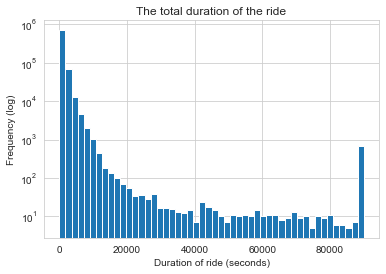

In [18]:
plt.hist(bike['ride_seconds'],bins=50,log=True) # NOTE this is log scale for the y-axis!
plt.xlabel("Duration of ride (seconds)")
plt.ylabel("Frequency (log)")
plt.title("The total duration of the ride")

Just by visualization, most of the rides can be categorized as "accidental unlocks" (where the duration is under a minute). Additionally, there are a few rides that are longer than 24-hours. Those may indicate logging issues or unusual edge cases. Next, I'll apply a filter to exclude these (i.e. excluding anything under a minute or anything over 15 hours).

In [19]:
# Remove unrealistic ride durations
bike = bike[(bike["ride_seconds"] > 60) & (bike["ride_seconds"] < 18000)] # 43200 seconds is 12 hours

Text(0.5, 1.0, 'Total duration of the ride excluding anamolies')

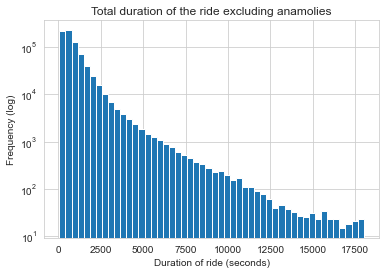

In [20]:
plt.hist(bike['ride_seconds'],bins=50, log=True) # NOTE this is log scale for the y-axis!
# plt.hist(bike['ride_seconds'],bins=50) # NOTE this is log scale for the y-axis!
plt.xlabel("Duration of ride (seconds)")
plt.ylabel("Frequency (log)")
plt.title("Total duration of the ride excluding anamolies")

After filtering unrealistic durations, the ride-length distribution becomes more interpretable. Most rides now fall within a plausible short-to-moderate trip range, which is more consistent with typical urban bike-share usage.

In addition to cleaning the duration field, I create time-based features such as hour of day, weekday, and weekend indicators. These variables are important because ridership patterns are strongly shaped by commuting and leisure timing, and they help separate weather effects from normal daily or weekly demand cycles.

In [21]:
# Create time-based features
bike['started_at'] = pd.to_datetime(bike['started_at'])
bike['ended_at'] = pd.to_datetime(bike['ended_at'])
weather['time'] = pd.to_datetime(weather['time'])

bike["date"] = bike["started_at"].dt.date
bike["hour"] = bike["started_at"].dt.hour
bike["day"] = bike["started_at"].dt.day
bike["weekday"] = bike["started_at"].dt.day_name()
bike["month"] = bike["started_at"].dt.month
bike["is_weekend"] = bike["started_at"].dt.weekday >= 5
bike["weather_hour"] = bike["started_at"].dt.floor("h")

/Users/julia/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/Users/julia/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until
/Users/julia/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_

## Merge Bike and Weather Data
Since the weather data is hourly, merge each trip to the weather observed during its trip start hour. I am assuming the weather conditions at trip start influence the decision to begin a ride, therefore each trip is matched to the weather observed during the hour the ride began.

EXAMPLE:
Trip start = 08:37
Weather used = 08:00 hourly observation

LIMITATIONS:
- weather may vary within the hour
- weather may vary geographically across the city
- longer rides may experience changing weather

In [22]:
df = bike.merge(
    weather,
    left_on="weather_hour", # where to merge in weather df
    right_on="time", # where to merge in bike df
    how="left" # keeps all rows from the left df and brings in matching rows from the right df; 
               #    non-matching rows in the right df will be filled with NaN
)

In [23]:
print("Merged shape:", df.shape)
display(df.head())

Merged shape: (765734, 40)


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_length,h,m,s,ride_seconds,date,hour,day,weekday,month,is_weekend,weather_hour,time,temp,apparent_temperature,dewpoint,humidity,precipitation,rain,showers,snowfall,windspeed_10m,windgusts_10m,winddirection_10m,visibility,cloudcover,is_day
0,5C00A6B5A60E4AFC,electric_bike,2025-08-28 15:56:46.803,2025-08-28 16:11:54.890,Clinton St & Madison St,CHI00233,New St & Illinois St,CHI00279,41.88,-87.64,41.89,-87.62,casual,00:15:08,00,15,08,908,2025-08-28,15,28,Thursday,8,False,2025-08-28 15:00:00,2025-08-28 15:00:00,70.4,72.6,60.8,72.0,0.02,0.02,0.0,0.0,6.0,19.7,22.0,NaN,69.0,1.0
1,FB25D4B923656D01,electric_bike,2025-08-27 19:15:53.059,2025-08-27 19:34:13.683,NaN,NaN,NaN,NaN,41.95,-87.64,41.89,-87.61,casual,00:18:20,00,18,20,1100,2025-08-27,19,27,Wednesday,8,False,2025-08-27 19:00:00,2025-08-27 19:00:00,71.6,68.8,50.7,48.0,0.00,0.00,0.0,0.0,7.2,19.5,228.0,NaN,67.0,1.0
2,C665B0EC937C860C,electric_bike,2025-08-27 20:27:31.394,2025-08-27 20:38:29.890,Halsted St & Dickens Ave,CHI00291,NaN,NaN,41.92,-87.65,41.90,-87.64,casual,00:10:58,00,10,58,658,2025-08-27,20,27,Wednesday,8,False,2025-08-27 20:00:00,2025-08-27 20:00:00,69.8,68.2,52.4,54.0,0.00,0.00,0.0,0.0,5.6,13.4,235.0,NaN,6.0,1.0
3,C68C54D5FD9717C2,electric_bike,2025-08-28 15:33:21.055,2025-08-28 15:39:58.052,Peoria St & Kinzie St,CHI02098,NaN,NaN,41.89,-87.65,41.88,-87.65,casual,00:06:36,00,06,36,396,2025-08-28,15,28,Thursday,8,False,2025-08-28 15:00:00,2025-08-28 15:00:00,70.4,72.6,60.8,72.0,0.02,0.02,0.0,0.0,6.0,19.7,22.0,NaN,69.0,1.0
4,902D69C29B0E65F8,electric_bike,2025-08-28 09:59:44.846,2025-08-28 10:11:17.343,NaN,NaN,NaN,NaN,41.98,-87.68,41.95,-87.70,casual,00:11:32,00,11,32,692,2025-08-28,9,28,Thursday,8,False,2025-08-28 09:00:00,2025-08-28 09:00:00,64.8,65.2,60.6,86.0,0.00,0.00,0.0,0.0,7.6,17.7,270.0,NaN,22.0,1.0


The merged dataset provides the core analytical table for the rest of the notebook: each trip now includes both rider and station information as well as the weather conditions present at the start of the ride.

In [24]:
# Check remaining missing values after merge
df.isnull().sum().sort_values(ascending=False).head(20)

visibility              765734
end_station_name         94660
end_station_id           94660
start_station_name       92054
start_station_id         92054
is_day                      88
windspeed_10m               88
humidity                    88
precipitation               88
rain                        88
showers                     88
snowfall                    88
windgusts_10m               88
temp                        88
time                        88
apparent_temperature        88
winddirection_10m           88
cloudcover                  88
dewpoint                    88
end_lng                      8
dtype: int64

## Data Quality Review

After merging, I do one final quality review to confirm that the combined bike-weather dataset is usable for downstream analysis. This includes checking remaining missingness, ride-duration outliers, and the distributions of key weather variables.

In [25]:
# Missing values (percent)
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0]

visibility              100.000000
end_station_name         12.361995
end_station_id           12.361995
start_station_name       12.021668
start_station_id         12.021668
is_day                    0.011492
windspeed_10m             0.011492
humidity                  0.011492
precipitation             0.011492
rain                      0.011492
showers                   0.011492
snowfall                  0.011492
windgusts_10m             0.011492
temp                      0.011492
time                      0.011492
apparent_temperature      0.011492
winddirection_10m         0.011492
cloudcover                0.011492
dewpoint                  0.011492
end_lng                   0.001045
end_lat                   0.001045
dtype: float64

Missing 100% of the visibility data which is unfortunate, but I don't see an obvious way to recover this. Still missing about 12% of the station names and ID's (even with the recovery effort), a more robust effort may be needed. Less than 1% missing data for the rest of the variables which is good!

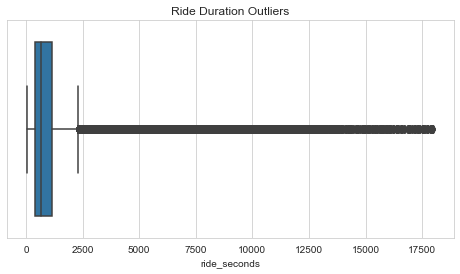

count    765734.000000
mean        970.453579
std        1090.380683
min          61.000000
25%         386.000000
50%         659.000000
75%        1148.000000
max       17992.000000
Name: ride_seconds, dtype: float64

In [26]:
# Ride duration outliers
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["ride_seconds"])
plt.title("Ride Duration Outliers")
plt.show()
df["ride_seconds"].describe()

Even after filtering, the ride-duration boxplot still shows a long right tail, which is expected for real-world trip data. A small number of long rides remain, but they appear to represent true variability rather than obvious data-entry errors.

In [27]:
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_length,h,m,s,ride_seconds,date,hour,day,weekday,month,is_weekend,weather_hour,time,temp,apparent_temperature,dewpoint,humidity,precipitation,rain,showers,snowfall,windspeed_10m,windgusts_10m,winddirection_10m,visibility,cloudcover,is_day
0,5C00A6B5A60E4AFC,electric_bike,2025-08-28 15:56:46.803,2025-08-28 16:11:54.890,Clinton St & Madison St,CHI00233,New St & Illinois St,CHI00279,41.88,-87.64,41.89,-87.62,casual,00:15:08,00,15,08,908,2025-08-28,15,28,Thursday,8,False,2025-08-28 15:00:00,2025-08-28 15:00:00,70.4,72.6,60.8,72.0,0.02,0.02,0.0,0.0,6.0,19.7,22.0,NaN,69.0,1.0
1,FB25D4B923656D01,electric_bike,2025-08-27 19:15:53.059,2025-08-27 19:34:13.683,NaN,NaN,NaN,NaN,41.95,-87.64,41.89,-87.61,casual,00:18:20,00,18,20,1100,2025-08-27,19,27,Wednesday,8,False,2025-08-27 19:00:00,2025-08-27 19:00:00,71.6,68.8,50.7,48.0,0.00,0.00,0.0,0.0,7.2,19.5,228.0,NaN,67.0,1.0
2,C665B0EC937C860C,electric_bike,2025-08-27 20:27:31.394,2025-08-27 20:38:29.890,Halsted St & Dickens Ave,CHI00291,NaN,NaN,41.92,-87.65,41.90,-87.64,casual,00:10:58,00,10,58,658,2025-08-27,20,27,Wednesday,8,False,2025-08-27 20:00:00,2025-08-27 20:00:00,69.8,68.2,52.4,54.0,0.00,0.00,0.0,0.0,5.6,13.4,235.0,NaN,6.0,1.0
3,C68C54D5FD9717C2,electric_bike,2025-08-28 15:33:21.055,2025-08-28 15:39:58.052,Peoria St & Kinzie St,CHI02098,NaN,NaN,41.89,-87.65,41.88,-87.65,casual,00:06:36,00,06,36,396,2025-08-28,15,28,Thursday,8,False,2025-08-28 15:00:00,2025-08-28 15:00:00,70.4,72.6,60.8,72.0,0.02,0.02,0.0,0.0,6.0,19.7,22.0,NaN,69.0,1.0
4,902D69C29B0E65F8,electric_bike,2025-08-28 09:59:44.846,2025-08-28 10:11:17.343,NaN,NaN,NaN,NaN,41.98,-87.68,41.95,-87.70,casual,00:11:32,00,11,32,692,2025-08-28,9,28,Thursday,8,False,2025-08-28 09:00:00,2025-08-28 09:00:00,64.8,65.2,60.6,86.0,0.00,0.00,0.0,0.0,7.6,17.7,270.0,NaN,22.0,1.0


In [28]:
# Weather distributions and anomalies
weather_cols = [c for c in ["temp", "apparent_temperature", "dewpoint", "humidity", "precipitation", "rain", "showers", "snowfall", "windspeed_10m", "windgusts_10m", "cloudcover"] if c in df.columns]

df[weather_cols].describe()

,temp,apparent_temperature,dewpoint,humidity,precipitation,rain,showers,snowfall,windspeed_10m,windgusts_10m,cloudcover
count,765646.000000,765646.000000,765646.000000,765646.000000,765646.000000,765646.000000,765646.0,765646.0,765646.000000,765646.000000,765646.000000
mean,74.982854,77.473038,62.006955,65.969938,0.001425,0.001425,0.0,0.0,6.346581,17.025077,44.377173
std,7.746073,9.692194,7.275044,15.497837,0.010682,0.010682,0.0,0.0,2.484578,5.659629,40.821949
min,56.000000,53.200000,41.200000,33.000000,0.000000,0.000000,0.0,0.0,0.400000,1.600000,0.000000
25%,70.100000,70.100000,56.800000,53.000000,0.000000,0.000000,0.0,0.0,4.500000,12.800000,2.000000
50%,73.800000,77.100000,63.700000,66.000000,0.000000,0.000000,0.0,0.0,6.200000,17.000000,35.000000
75%,79.000000,83.700000,67.600000,79.000000,0.000000,0.000000,0.0,0.0,8.100000,21.000000,94.000000
max,92.800000,102.000000,74.600000,100.000000,0.256000,0.256000,0.0,0.0,13.100000,31.500000,100.000000


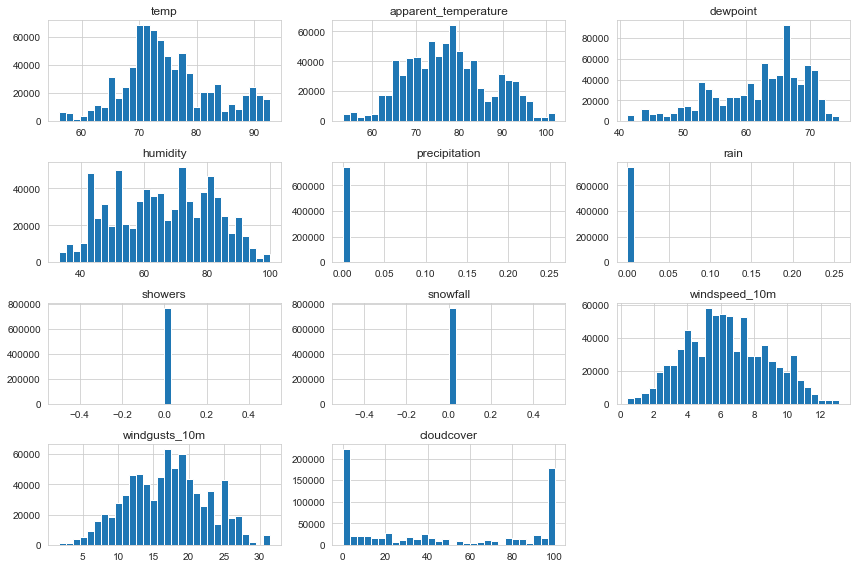

In [29]:
df[weather_cols].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()
# ** come back to this -> can probably clean up a bit

### Summary:
Add here!

------------------------------------------------

# II. Exploratory Analysis


## How Ridership Varies Across Time

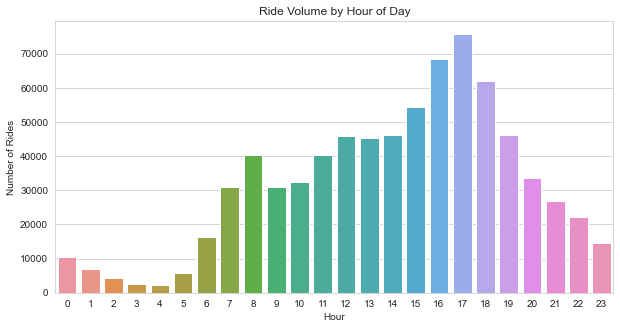

In [30]:
# Ridership by hour
hourly_rides = df.groupby("hour").size().reset_index(name="ride_count")

plt.figure(figsize=(10, 5))
sns.barplot(data=hourly_rides, x="hour", y="ride_count")
plt.title("Ride Volume by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Rides")
plt.show()

This plot shows how ridership changes throughout the day. Ride activity is very low during the overnight hours (roughly 12 AM–5 AM), then increases sharply beginning around 6–8 AM, corresponding to the morning commute period. After a moderate midday plateau, ridership rises again and reaches its highest levels in the late afternoon and early evening (around 4–6 PM), peaking near 5 PM. Following this peak, ride volume steadily declines through the evening.

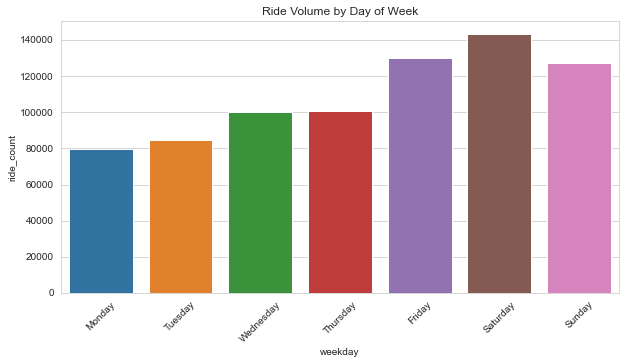

In [31]:
# Ridership by weekday
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekday_rides = (
    df.groupby("weekday")
    .size()
    .reindex(weekday_order)
    .reset_index(name="ride_count")
)

plt.figure(figsize=(10, 5))
sns.barplot(data=weekday_rides, x="weekday", y="ride_count", order=weekday_order)
plt.title("Ride Volume by Day of Week")
plt.xticks(rotation=45)
plt.show()

This plot illustrates overall ride counts by weekday. Ridership generally increases gradually from Monday through Friday, with Friday and Saturday showing the highest overall ride counts. Saturday has the largest number of rides, suggesting strong recreational or leisure use during the weekend. Sunday ridership remains relatively high but slightly lower than Saturday. Weekdays earlier in the week, particularly Monday and Tuesday, show the lowest overall ride totals.

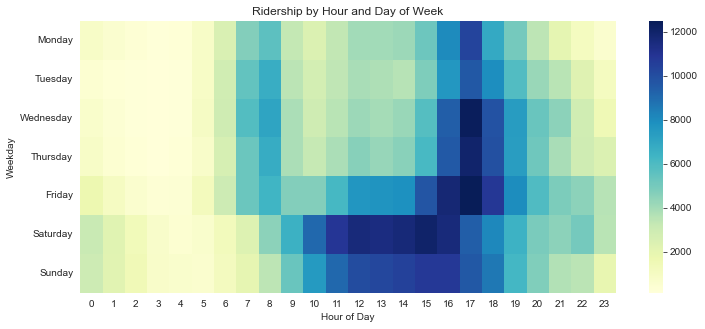

In [32]:
# Hour by weekday heatmap
hour_weekday = (
    df.groupby(["weekday", "hour"])
    .size()
    .reset_index(name="ride_count")
)

hour_weekday["weekday"] = pd.Categorical(hour_weekday["weekday"], categories=weekday_order, ordered=True)
hour_weekday = hour_weekday.sort_values(["weekday", "hour"])

pivot_hw = hour_weekday.pivot(index="weekday", columns="hour", values="ride_count")

plt.figure(figsize=(12, 5))
sns.heatmap(pivot_hw, cmap="YlGnBu")
plt.title("Ridership by Hour and Day of Week")
plt.xlabel("Hour of Day")
plt.ylabel("Weekday")
plt.show()

The heatmap combines both time-of-day and day-of-week patterns. On weekdays, two distinct peaks appear: a morning commute peak (around 7–9 AM) and a stronger evening commute peak (around 4–6 PM). On weekends, the pattern changes noticeably—morning commute peaks disappear, and ridership instead builds gradually throughout the morning and peaks during the midday and afternoon hours (around 11 AM–4 PM). Weekend evenings remain moderately active compared to weekdays.

### Summary:
Ridership volume varies systematically throughout both the day and the week, revealing behavioral patterns. During weekdays, bike usage strongly follows typical commuting patterns, with peaks during the morning and especially the late afternoon commute. Evening commute hours appear to generate the highest ride volumes overall. In contrast, weekend ridership shifts toward leisure-oriented behavior, with activity concentrated in the late morning and afternoon rather than early commute hours. Additionally, overall ride volume tends to increase toward the end of the workweek, with Friday and Saturday showing the highest total ridership. These patterns suggest the bike-share system supports both daily commuting needs during the week and recreational or flexible travel during weekends, which has implications for bike redistribution and station management throughout the day and across different days of the week.

## Weather and Ridership
This section investigates how weather conditions influence bike-share demand. Because the weather data is recorded hourly while bike trips are recorded at the individual ride level, the analysis aggregates ride counts by hour before examining relationships with weather variables. This ensures the units of comparison align and prevents busy hours from being overweighted simply because they contain more trip records.

The key question is whether changes in weather conditions—such as temperature, rainfall, wind, or visibility—correspond to changes in ride demand.

In [33]:
# Aggregate the rides to the hourly level so they can be directly compared with hourly weather observations

hourly_df = df.groupby("weather_hour").size().reset_index(name="ride_count")

hourly_df = hourly_df.merge(
    weather,
    left_on="weather_hour",
    right_on="time",
    how="left"
)
hourly_df.head(20)

,weather_hour,ride_count,time,temp,apparent_temperature,dewpoint,humidity,precipitation,rain,showers,snowfall,windspeed_10m,windgusts_10m,winddirection_10m,visibility,cloudcover,is_day
0,2025-07-31 20:00:00,1,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-07-31 21:00:00,2,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-07-31 22:00:00,6,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-07-31 23:00:00,79,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-08-01 00:00:00,342,2025-08-01 00:00:00,66.2,64.9,58.5,76.0,0.0,0.0,0.0,0.0,9.8,23.0,7.0,NaN,74.0,1.0
5,2025-08-01 01:00:00,333,2025-08-01 01:00:00,66.1,66.6,60.7,83.0,0.0,0.0,0.0,0.0,7.6,20.8,4.0,NaN,100.0,1.0
6,2025-08-01 02:00:00,170,2025-08-01 02:00:00,66.3,68.9,63.2,90.0,0.0,0.0,0.0,0.0,4.9,15.9,21.0,NaN,100.0,1.0
7,2025-08-01 03:00:00,77,2025-08-01 03:00:00,66.6,69.2,64.0,91.0,0.0,0.0,0.0,0.0,5.8,11.6,58.0,NaN,97.0,1.0
8,2025-08-01 04:00:00,87,2025-08-01 04:00:00,66.3,68.5,63.0,89.0,0.0,0.0,0.0,0.0,5.8,12.5,71.0,NaN,88.0,1.0
9,2025-08-01 05:00:00,243,2025-08-01 05:00:00,65.4,67.8,62.5,90.0,0.0,0.0,0.0,0.0,4.8,12.1,77.0,NaN,16.0,1.0


Each row in this hourly dataset now represents the total number of rides taken during a given hour, along with the weather conditions observed during that same hour. This structure makes it possible to compare system-wide ridership directly against temperature, precipitation, and other weather variables.

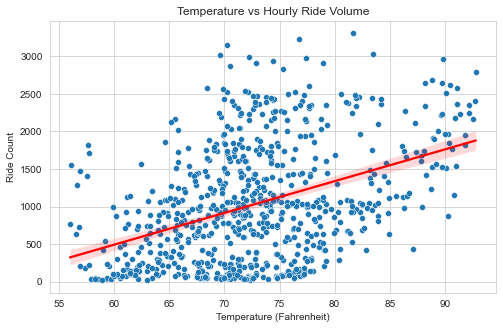

In [34]:
# Temperature vs Ride Volume

plt.figure(figsize=(8, 5))

sns.scatterplot(data=hourly_df, x="temp", y="ride_count")
sns.regplot(data=hourly_df, x="temp", y="ride_count", color='red',scatter=False)

plt.title("Temperature vs Hourly Ride Volume")
plt.xlabel("Temperature (Fahrenheit)")
plt.ylabel("Ride Count")
plt.show()

Ride demand generally increases with warmer temperatures up to comfortable levels. Because the dataset focuses on August, most observations occur within a warm range, so the effect is relatively moderate. Extremely high temperatures may slightly reduce ridership as outdoor activity becomes less comfortable.

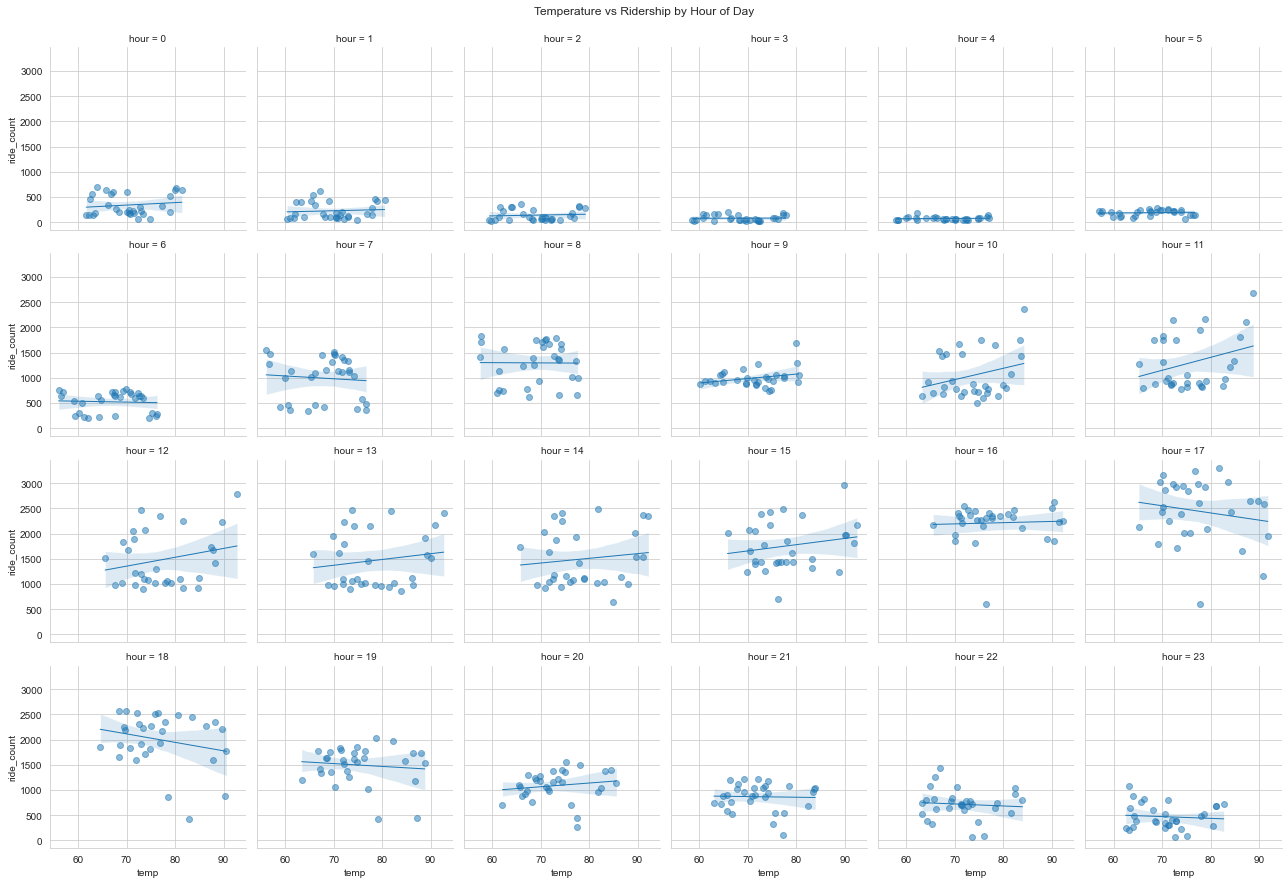

In [35]:
# Does the Temperature Relationship Vary by Time of Day?
hourly_df["hour"] = hourly_df["weather_hour"].dt.hour

g = sns.lmplot(
    data=hourly_df,
    x="temp",
    y="ride_count",
    col="hour",
    col_wrap=6,
    height=3,
    scatter_kws={"alpha": 0.5},
    line_kws={"linewidth": 1}
)

g.fig.suptitle("Temperature vs Ridership by Hour of Day", y=1.02)

plt.show()

Hourly ride volume generally increases as temperatures rise, even within a single summer month. Although August only captures warm-season conditions, the upward trend still suggests that more comfortable weather is associated with stronger bike-share demand.

Hourly subplots are detailed but visually dense, so grouping hours into broader behavioral periods provides a cleaner way to compare how temperature affects commuting, midday, and low-demand riding windows.

In [36]:
# Temperature Effects by Time-of-Day Group
def hour_bucket(h):
    if 5 <= h < 10:
        return "Morning commute"
    elif 10 <= h < 16:
        return "Midday"
    elif 16 <= h < 20:
        return "Evening commute"
    else:
        return "Night / Early morning"

hourly_df["time_period"] = hourly_df["hour"].apply(hour_bucket)

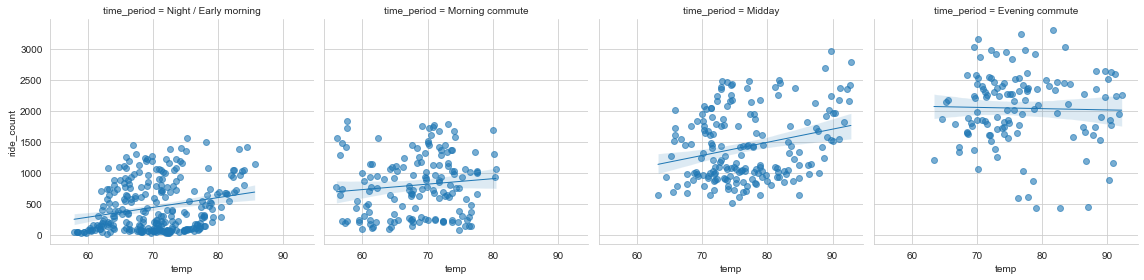

In [37]:
sns.lmplot(
    data=hourly_df,
    x="temp",
    y="ride_count",
    col="time_period",
    height=4,
    scatter_kws={"alpha": 0.6},
    line_kws={"linewidth": 1}
)

plt.show()

Grouping hours into time-of-day periods helps reveal behavioral patterns:

- Morning commute: ridership may be relatively stable regardless of weather
- Midday: leisure trips may increase when temperatures are comfortable
- Evening commute: often shows the highest demand
- Night: consistently low ridership

In [38]:
# Weather-Conditioned Ridership Curves (rainy vs dry hours)

hourly_df["rain_event"] = hourly_df["rain"] > 0

rain_hourly = hourly_df.groupby(["hour","rain_event"])["ride_count"].mean().reset_index()

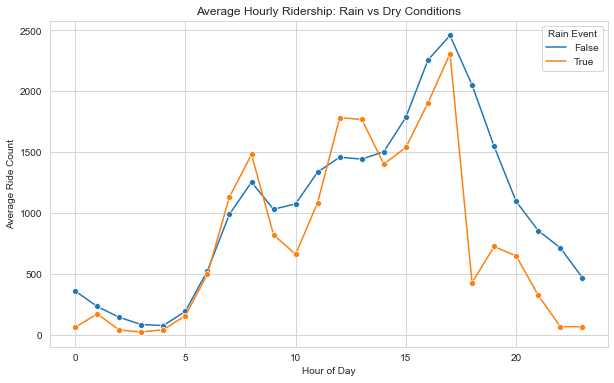

In [39]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=rain_hourly,
    x="hour",
    y="ride_count",
    hue="rain_event",
    marker="o"
)

plt.title("Average Hourly Ridership: Rain vs Dry Conditions")

plt.xlabel("Hour of Day")
plt.ylabel("Average Ride Count")

plt.legend(title="Rain Event")

plt.show()

Rain suppresses ridership across nearly the entire day, but the gap between rainy and dry conditions is especially noticeable during peak demand hours. This suggests that unfavorable weather reduces both commuting and nonessential trips, though the effect appears strongest when overall demand would otherwise be high.

### Summary:
Add here!

## Weather Effects by Rider Type

Weather likely affects member and casual riders differently. Members are more likely to use bike-share for routine or commute-related travel, while casual riders may be more sensitive to weather because their trips are more discretionary or recreational. To better understand weather impacts, I compare ridership patterns across rider types under rain and dry conditions.

Aggregating ridership by both hour and rider type makes it possible to compare how the two groups respond to the same weather conditions over time.

In [40]:
# Hourly ridership split by rider type
hourly_rider_df = (
    df.groupby(["weather_hour", "member_casual"])
      .size()
      .reset_index(name="ride_count")
)

# Merge in weather data
hourly_rider_df = hourly_rider_df.merge(
    weather,
    left_on="weather_hour",
    right_on="time",
    how="left"
)

# Add hour feature
hourly_rider_df["hour"] = hourly_rider_df["weather_hour"].dt.hour


In [41]:
hourly_rider_df.head(30)

,weather_hour,member_casual,ride_count,time,temp,apparent_temperature,dewpoint,humidity,precipitation,rain,showers,snowfall,windspeed_10m,windgusts_10m,winddirection_10m,visibility,cloudcover,is_day,hour
0,2025-07-31 20:00:00,casual,1,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20
1,2025-07-31 21:00:00,casual,1,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21
2,2025-07-31 21:00:00,member,1,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21
3,2025-07-31 22:00:00,casual,5,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22
4,2025-07-31 22:00:00,member,1,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22
5,2025-07-31 23:00:00,casual,45,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23
6,2025-07-31 23:00:00,member,34,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23
7,2025-08-01 00:00:00,casual,180,2025-08-01 00:00:00,66.2,64.9,58.5,76.0,0.0,0.0,0.0,0.0,9.8,23.0,7.0,NaN,74.0,1.0,0
8,2025-08-01 00:00:00,member,162,2025-08-01 00:00:00,66.2,64.9,58.5,76.0,0.0,0.0,0.0,0.0,9.8,23.0,7.0,NaN,74.0,1.0,0
9,2025-08-01 01:00:00,casual,207,2025-08-01 01:00:00,66.1,66.6,60.7,83.0,0.0,0.0,0.0,0.0,7.6,20.8,4.0,NaN,100.0,1.0,1


In [42]:
hourly_rider_df["rain_event"] = hourly_rider_df["rain"] > 0

rain_type_summary = (
    hourly_rider_df.groupby(["member_casual", "rain_event"])["ride_count"]
    .mean()
    .reset_index()
)

display(rain_type_summary)

,member_casual,rain_event,ride_count
0,casual,False,437.658926
1,casual,True,360.610169
2,member,False,589.225291
3,member,True,636.000000


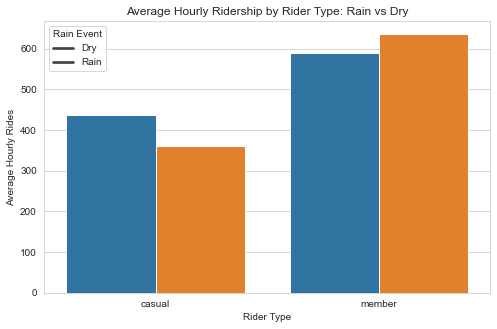

In [43]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=rain_type_summary,
    x="member_casual",
    y="ride_count",
    hue="rain_event"
)

plt.title("Average Hourly Ridership by Rider Type: Rain vs Dry")
plt.xlabel("Rider Type")
plt.ylabel("Average Hourly Rides")
plt.legend(title="Rain Event", labels=["Dry", "Rain"])
plt.show()

Rain reduces ridership for both groups, but the drop is much larger for casual riders. Member demand appears comparatively resilient, suggesting that many member trips are tied to routine transportation needs rather than optional or weather-dependent travel.

In [44]:
hourly_rain_type = (
    hourly_rider_df.groupby(["hour", "member_casual", "rain_event"])["ride_count"]
    .mean()
    .reset_index()
)

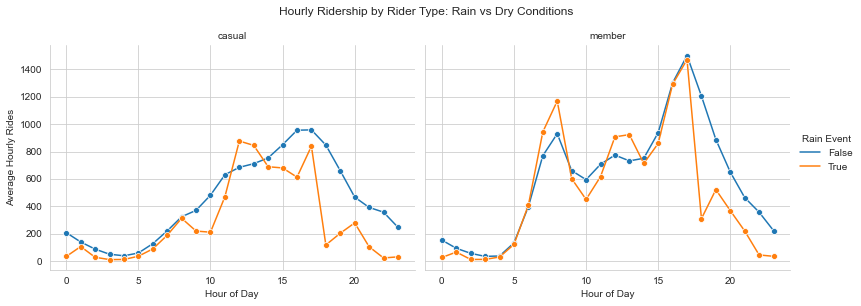

In [45]:
g = sns.FacetGrid(
    hourly_rain_type,
    col="member_casual",
    height=4,
    aspect=1.4
)

g.map_dataframe(
    sns.lineplot,
    x="hour",
    y="ride_count",
    hue="rain_event",
    marker="o"
)

g.add_legend(title="Rain Event")
g.set_axis_labels("Hour of Day", "Average Hourly Rides")
g.set_titles("{col_name}")
g.fig.suptitle("Hourly Ridership by Rider Type: Rain vs Dry Conditions", y=1.05)

plt.show()

The hourly rider-type plots reinforce this difference: member demand remains present even under rainy conditions, especially during commuting hours, while casual ridership falls off much more sharply. This suggests that weather-sensitive demand is driven primarily by discretionary rather than routine trips.

To quantify these differences more directly, I fit separate rider-type models and compare the estimated weather coefficients for members and casual riders.

In [46]:
weather_features = [
    "temp",
    "apparent_temperature",
    "humidity",
    "precipitation",
    "rain",
    "windspeed_10m",
    "windgusts_10m",
    "cloudcover"
]

member_models = {}

for rider_type in ["member", "casual"]:
    sub = hourly_rider_df[hourly_rider_df["member_casual"] == rider_type].copy()
    
    model_df = sub[["ride_count", "hour"] + weather_features].copy()
    
    for col in ["ride_count", "hour"] + weather_features:
        model_df[col] = pd.to_numeric(model_df[col], errors="coerce")
    
    model_df = model_df.replace([np.inf, -np.inf], np.nan).dropna()
    
    hour_dummies = pd.get_dummies(model_df["hour"], prefix="hour", drop_first=True)
    X = pd.concat([model_df[weather_features], hour_dummies], axis=1)
    X = sm.add_constant(X).astype(float)
    
    y = model_df["ride_count"].astype(float)
    
    fit = sm.OLS(y, X).fit()
    member_models[rider_type] = fit

/Users/julia/anaconda3/lib/python3.7/site-packages/statsmodels/tsa/tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


In [47]:
coef_compare = pd.DataFrame({
    "feature": member_models["member"].params.index,
    "member_coef": member_models["member"].params.values,
    "casual_coef": member_models["casual"].params.values
})

coef_compare = coef_compare[coef_compare["feature"].isin(weather_features)]
display(coef_compare)

,feature,member_coef,casual_coef
1,temp,7.290004,42.330799
2,apparent_temperature,-5.740381,-27.055748
3,humidity,0.767451,0.668381
4,precipitation,-362.714214,-494.500999
5,rain,-362.714214,-494.500999
6,windspeed_10m,18.865999,-9.520298
7,windgusts_10m,-9.161688,-4.760872
8,cloudcover,-0.139012,-0.613690


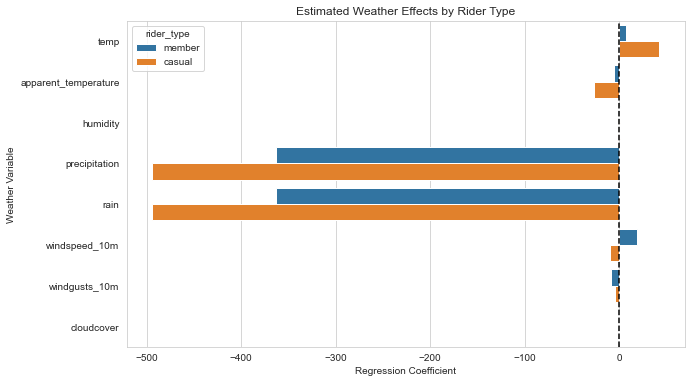

In [48]:
coef_long = coef_compare.melt(
    id_vars="feature",
    value_vars=["member_coef", "casual_coef"],
    var_name="rider_type",
    value_name="coefficient"
)

coef_long["rider_type"] = coef_long["rider_type"].str.replace("_coef", "")

plt.figure(figsize=(10, 6))

sns.barplot(
    data=coef_long,
    x="coefficient",
    y="feature",
    hue="rider_type"
)

plt.axvline(0, color="black", linestyle="--")
plt.title("Estimated Weather Effects by Rider Type")
plt.xlabel("Regression Coefficient")
plt.ylabel("Weather Variable")
plt.show()

The coefficient comparison supports the visual analysis: casual ridership is more sensitive to weather-related variables than member ridership. In other words, favorable weather appears to unlock additional discretionary demand rather than substantially altering the core commuter base.

In [49]:
df["rain_event"] = df["rain"] > 0

duration_weather_type = (
    df.groupby(["member_casual", "rain_event"])["ride_seconds"]
    .median()
    .reset_index()
)

display(duration_weather_type)

,member_casual,rain_event,ride_seconds
0,casual,False,807.0
1,casual,True,780.0
2,member,False,581.0
3,member,True,555.0


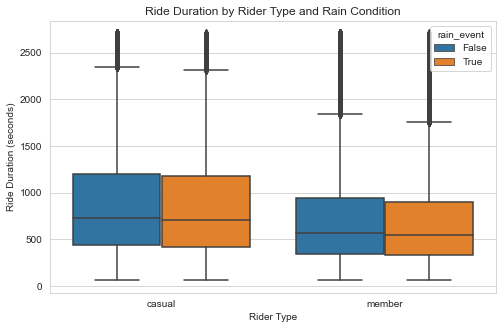

In [50]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df[df["ride_seconds"] < df["ride_seconds"].quantile(0.95)],
    x="member_casual",
    y="ride_seconds",
    hue="rain_event"
)

plt.title("Ride Duration by Rider Type and Rain Condition")
plt.xlabel("Rider Type")
plt.ylabel("Ride Duration (seconds)")
plt.show()

Once riders begin a trip, rain appears to have a smaller effect on trip duration than on the decision to ride at all. This suggests that weather mostly influences whether a trip happens, rather than meaningfully changing how long completed trips last.

### Summary:
Add here!

## Station Departure–Return Imbalance

Beyond total ridership, station-level bike flow can reveal operational pressure points in the system. This subsection looks at where bikes are consistently leaving faster than they return, which helps identify stations that may need more frequent rebalancing.

In [51]:
departures = df.groupby("start_station_name").size().reset_index(name="departures")

returns = df.groupby("end_station_name").size().reset_index(name="returns")

station_flow = departures.merge(
    returns,
    left_on="start_station_name",
    right_on="end_station_name",
    how="outer"
)

station_flow["station"] = station_flow["start_station_name"].fillna(station_flow["end_station_name"])

station_flow = station_flow.fillna(0)

station_flow["net_flow"] = station_flow["departures"] - station_flow["returns"]

Net flow is defined as departures minus returns. Stations with strongly positive net flow tend to lose bikes over time, while stations with strongly negative net flow tend to accumulate them.

In [52]:
top_outflow = station_flow.nlargest(10, "net_flow")
top_inflow = station_flow.nsmallest(10, "net_flow")

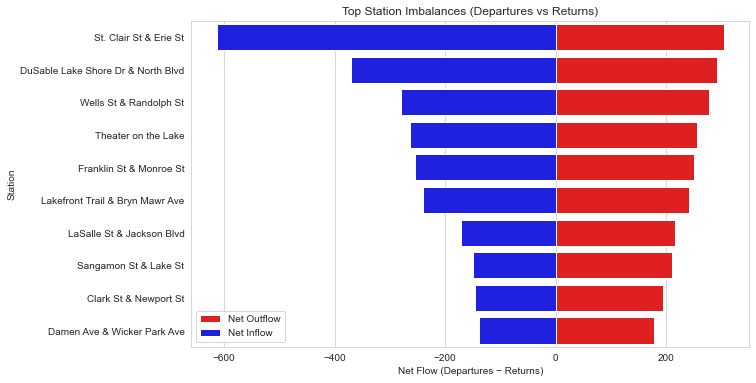

In [53]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_outflow,
    x="net_flow",
    y="station",
    color="red",
    label="Net Outflow"
)

sns.barplot(
    data=top_inflow,
    x="net_flow",
    y="station",
    color="blue",
    label="Net Inflow"
)

plt.title("Top Station Imbalances (Departures vs Returns)")
plt.xlabel("Net Flow (Departures − Returns)")
plt.ylabel("Station")

plt.legend()

plt.show()

The most imbalanced stations likely represent predictable origins or destinations in the network, such as residential, commuter, or leisure-heavy locations. These stations are especially relevant for operations because persistent imbalance creates a need for active bike redistribution.

To visualize these imbalances spatially, I merge the station-level net-flow table with average station coordinates derived from trip start locations. This allows imbalance patterns to be viewed geographically rather than only in a ranked chart.

In [54]:
# Build a station coordinate reference using known start station coordinates
start_coords = (
    df.loc[
        df["start_station_name"].notna() &
        df["start_lat"].notna() &
        df["start_lng"].notna(),
        ["start_station_name", "start_lat", "start_lng"]
    ]
    .groupby("start_station_name", as_index=False)
    .agg({
        "start_lat": "mean",
        "start_lng": "mean"
    })
    .rename(columns={
        "start_station_name": "station",
        "start_lat": "lat",
        "start_lng": "lng"
    })
)

# Build a second coordinate reference from end station coordinates
end_coords = (
    df.loc[
        df["end_station_name"].notna() &
        df["end_lat"].notna() &
        df["end_lng"].notna(),
        ["end_station_name", "end_lat", "end_lng"]
    ]
    .groupby("end_station_name", as_index=False)
    .agg({
        "end_lat": "mean",
        "end_lng": "mean"
    })
    .rename(columns={
        "end_station_name": "station",
        "end_lat": "lat",
        "end_lng": "lng"
    })
)

# Combine both sources of coordinates
station_coords = pd.concat([start_coords, end_coords], ignore_index=True)

# Average duplicate station coordinate entries
station_coords = (
    station_coords
    .groupby("station", as_index=False)
    .agg({
        "lat": "mean",
        "lng": "mean"
    })
)

# Merge coordinates into station flow table
station_map = station_flow.merge(
    station_coords,
    on="station",
    how="left"
)

# Drop rows where coordinates are missing
station_map = station_map.dropna(subset=["lat", "lng"]).copy()

# Remove perfectly balanced stations
station_map = station_map[station_map["net_flow"] != 0].copy()

print("Stations available for mapping:", len(station_map))

Stations available for mapping: 1212


In [55]:
# Center map on the mean station location
map_center = [station_map["lat"].mean(), station_map["lng"].mean()]
m = folium.Map(location=map_center, zoom_start=11)

for _, row in station_map.iterrows():
    color = "red" if row["net_flow"] > 0 else "blue"
    
    # Scale marker radius
    radius = max(3, min(15, abs(row["net_flow"])))
    
    folium.CircleMarker(
        location=[row["lat"], row["lng"]],
        radius=radius,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.6,
        popup=(
            f"Station: {row['station']}<br>"
            f"Departures: {int(row['departures'])}<br>"
            f"Returns: {int(row['returns'])}<br>"
            f"Net Flow: {int(row['net_flow'])}"
        )
    ).add_to(m)

m

Red circles indicate stations that lose bikes overall, while blue circles indicate stations that gain bikes. Larger circles represent larger absolute imbalances. Together, these patterns highlight areas where rebalancing operations may need to be concentrated.

## Summary:

Add here!

---------------------------------

# III. Modeling


## Citywide Demand Model (Weather + Time Effects)


This first model estimates how hourly ridership changes with weather conditions while controlling for hour-of-day effects. The goal is a clearer understanding of which weather variables are most associated with demand changes at the system level.

In [56]:
weather_features = [
    "temp",
    "apparent_temperature",
    "humidity",
    "precipitation",
    "rain",
    "windspeed_10m",
    "windgusts_10m",
    "cloudcover"
]

# Build model dataset
model_df = hourly_df[["ride_count", "hour"] + weather_features].copy()

# Convert to numeric and clean
for col in ["ride_count", "hour"] + weather_features:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

model_df = model_df.replace([np.inf, -np.inf], np.nan).dropna()

# Add hour fixed effects
hour_dummies = pd.get_dummies(model_df["hour"], prefix="hour", drop_first=True)

X = pd.concat([model_df[weather_features], hour_dummies], axis=1)
X = sm.add_constant(X).astype(float)

y = model_df["ride_count"].astype(float)

weather_model = sm.OLS(y, X).fit()

print(weather_model.summary())

                            OLS Regression Results                            
Dep. Variable:             ride_count   R-squared:                       0.779
Model:                            OLS   Adj. R-squared:                  0.769
Method:                 Least Squares   F-statistic:                     83.60
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          8.53e-211
Time:                        18:10:26   Log-Likelihood:                -5440.2
No. Observations:                 744   AIC:                         1.094e+04
Df Residuals:                     713   BIC:                         1.109e+04
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 -695.6191 

/Users/julia/anaconda3/lib/python3.7/site-packages/statsmodels/tsa/tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


The regression output provides a more formal way to evaluate the weather relationships seen earlier in the exploratory analysis. To make the model easier to interpret, the estimated coefficients are visualized below.

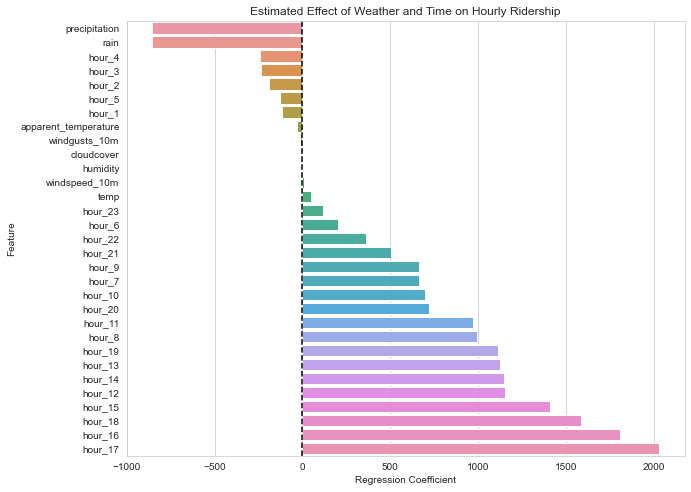

In [57]:
coef_df = pd.DataFrame({
    "feature": weather_model.params.index,
    "coefficient": weather_model.params.values
})

coef_df = coef_df[coef_df["feature"] != "const"]

plt.figure(figsize=(10, 8))

sns.barplot(
    data=coef_df.sort_values("coefficient"),
    x="coefficient",
    y="feature"
)

plt.axvline(0, color="black", linestyle="--")
plt.title("Estimated Effect of Weather and Time on Hourly Ridership")
plt.xlabel("Regression Coefficient")
plt.ylabel("Feature")
plt.show()

The coefficient plot summarizes the estimated contribution of each weather and time variable to hourly ridership. Positive coefficients indicate conditions associated with higher ride volume, while negative coefficients indicate conditions associated with lower ridership. The results broadly align with the exploratory findings: favorable weather supports demand, while less favorable conditions suppress it.

## Weather Sensitivity by Station

Weather does not affect every station equally. Some appear more resilient to poor conditions, while other experiencing larger demand swings. This subsection measures station-level sensitivity to identify where weather matters most operationally.


In [58]:
# Departures by station
departures = df.groupby("start_station_name").agg(
    departures=("ride_id", "count"),
    avg_duration=("ride_seconds", "mean"),
    morning_share=("hour", lambda x: ((x >= 7) & (x <= 9)).mean()),
    evening_share=("hour", lambda x: ((x >= 16) & (x <= 18)).mean()),
    weekend_share=("is_weekend", "mean")
).reset_index()

# Returns by station
returns = df.groupby("end_station_name").size().reset_index(name="returns")

station_behavior = departures.merge(
    returns,
    left_on="start_station_name",
    right_on="end_station_name",
    how="left"
)

station_behavior["returns"] = station_behavior["returns"].fillna(0)
station_behavior["net_flow"] = station_behavior["departures"] - station_behavior["returns"]

station_behavior["station"] = station_behavior["start_station_name"]

station_behavior = station_behavior[[
    "station",
    "departures",
    "returns",
    "net_flow",
    "avg_duration",
    "morning_share",
    "evening_share",
    "weekend_share"
]]

In [59]:
# Aggregate departures by station and hour
station_hour = (
    df.groupby(["start_station_name", "weather_hour"])
      .size()
      .reset_index(name="ride_count")
)

# Add hour feature
station_hour["hour"] = pd.to_datetime(station_hour["weather_hour"]).dt.hour

# Merge with weather
station_hour = station_hour.merge(
    weather,
    left_on="weather_hour",
    right_on="time",
    how="left"
)

# Merge with station behavior summary
station_hour = station_hour.merge(
    station_behavior[["station", "departures", "net_flow", "morning_share", "evening_share", "weekend_share"]],
    left_on="start_station_name",
    right_on="station",
    how="left"
)

# Create a station-level weather resilience metric:
# average ride count during "bad weather" vs normal weather
station_hour["bad_weather"] = (
    (station_hour["rain"] > 0) |
    (station_hour["windgusts_10m"] > station_hour["windgusts_10m"].quantile(0.75))
)

resilience = (
    station_hour.groupby(["start_station_name", "bad_weather"])["ride_count"]
    .mean()
    .unstack()
    .rename(columns={False: "normal_weather_rides", True: "bad_weather_rides"})
)

resilience["weather_resilience_ratio"] = (
    resilience["bad_weather_rides"] / resilience["normal_weather_rides"]
)

resilience = resilience.reset_index()

After calculating station-level weather resilience, I merge that metric back into the station behavior table so it can be used alongside demand and imbalance measures. This allows planning decisions to incorporate both how busy a station is and how stable its demand remains under poor weather.

In [60]:
station_planning = station_behavior.merge(
    resilience,
    left_on="station",
    right_on="start_station_name",
    how="left"
)

To rank candidate stations for added capacity or expansion, I create an expansion priority score that combines three interpretable components: total departures, net flow imbalance, and weather resilience. These features are standardized using z-scores so they can be combined on a comparable scale. The resulting score is meant to highlight stations that are busy, operationally stressed, and consistently valuable even under worse weather conditions.

In [61]:
# Fill missing resilience values conservatively
station_planning["weather_resilience_ratio"] = station_planning["weather_resilience_ratio"].fillna(0)

# Standardize components manually using z-scores
for col in ["departures", "net_flow", "weather_resilience_ratio"]:
    station_planning[f"{col}_z"] = (
        station_planning[col] - station_planning[col].mean()
    ) / station_planning[col].std()

# Build a simple interpretable score
station_planning["expansion_priority_score"] = (
    0.5 * station_planning["departures_z"] +
    0.3 * station_planning["net_flow_z"] +
    0.2 * station_planning["weather_resilience_ratio_z"]
)

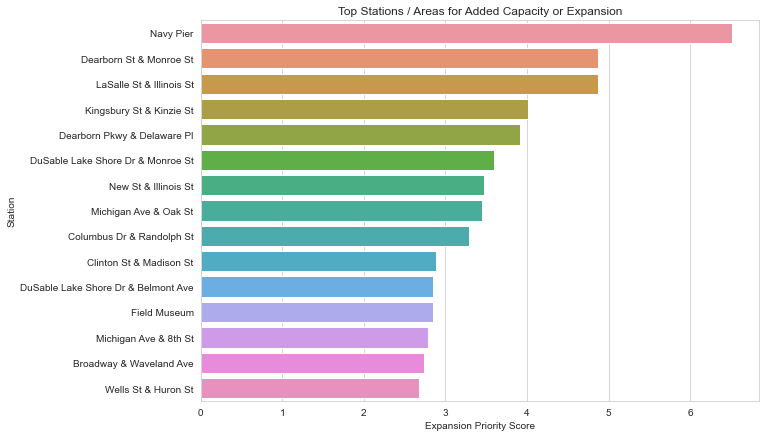

In [62]:
top_candidates = station_planning.sort_values(
    "expansion_priority_score",
    ascending=False
).head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_candidates,
    x="expansion_priority_score",
    y="station"
)

plt.title("Top Stations / Areas for Added Capacity or Expansion")
plt.xlabel("Expansion Priority Score")
plt.ylabel("Station")
plt.show()

The top-ranked stations in this plot are the strongest candidates for added dock capacity, nearby stations, or closer operational monitoring. These locations combine high demand with imbalance and relative weather resilience, suggesting that they are persistently important parts of the network rather than temporary or purely recreational hotspots.

## Weather-Informed Station Expansion Using a Greedy Approach

Add here!

First, identify trips that occur during favorable weather conditions, since these represent the demand most likely to increase when weather improves.

In [63]:
weather_sensitive_trips = df[
    (df["temp"] > 70) &
    (df["rain"] == 0) &
    (df["member_casual"] == "casual")
].copy()

weather_sensitive_trips.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_length,h,m,s,ride_seconds,date,hour,day,weekday,month,is_weekend,weather_hour,time,temp,apparent_temperature,dewpoint,humidity,precipitation,rain,showers,snowfall,windspeed_10m,windgusts_10m,winddirection_10m,visibility,cloudcover,is_day,rain_event
1,FB25D4B923656D01,electric_bike,2025-08-27 19:15:53.059,2025-08-27 19:34:13.683,NaN,NaN,NaN,NaN,41.95,-87.64,41.89,-87.61,casual,00:18:20,00,18,20,1100,2025-08-27,19,27,Wednesday,8,False,2025-08-27 19:00:00,2025-08-27 19:00:00,71.6,68.8,50.7,48.0,0.0,0.0,0.0,0.0,7.2,19.5,228.0,NaN,67.0,1.0,False
7,DB89E463719D72C0,electric_bike,2025-08-28 12:54:20.107,2025-08-28 12:59:02.320,Clinton St & Madison St,CHI00233,Kingsbury St & Kinzie St,CHI00299,41.88,-87.64,41.89,-87.64,casual,00:04:42,00,04,42,282,2025-08-28,12,28,Thursday,8,False,2025-08-28 12:00:00,2025-08-28 12:00:00,72.9,78.3,61.8,68.0,0.0,0.0,0.0,0.0,2.8,14.1,344.0,NaN,10.0,1.0,False
8,A3437BCA65687B4B,electric_bike,2025-08-28 13:42:02.905,2025-08-28 13:55:33.034,LaSalle St & Illinois St,CHI00358,Lincoln Ave & Dickens Ave,CHI02112,41.89,-87.63,41.92,-87.64,casual,00:13:30,00,13,30,810,2025-08-28,13,28,Thursday,8,False,2025-08-28 13:00:00,2025-08-28 13:00:00,73.8,79.2,61.2,65.0,0.0,0.0,0.0,0.0,3.8,15.2,30.0,NaN,34.0,1.0,False
9,BE04ABB8E33EE9A2,electric_bike,2025-08-28 11:16:46.381,2025-08-28 11:21:46.928,NaN,NaN,NaN,NaN,41.87,-87.61,41.86,-87.62,casual,00:05:00,00,05,00,300,2025-08-28,11,28,Thursday,8,False,2025-08-28 11:00:00,2025-08-28 11:00:00,70.9,74.5,61.7,73.0,0.0,0.0,0.0,0.0,4.2,15.0,304.0,NaN,12.0,1.0,False
16,F887DB4548EE7F52,electric_bike,2025-08-28 11:08:22.335,2025-08-28 11:21:10.419,NaN,NaN,NaN,NaN,41.88,-87.75,41.87,-87.69,casual,00:12:48,00,12,48,768,2025-08-28,11,28,Thursday,8,False,2025-08-28 11:00:00,2025-08-28 11:00:00,70.9,74.5,61.7,73.0,0.0,0.0,0.0,0.0,4.2,15.0,304.0,NaN,12.0,1.0,False


Next: seperate into grid

# Conclusion

Add here!